# PHASE 4 — PYTHON DATA CLEANING

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
customers = pd.read_excel(r'C:\Users\Ram Narvariya\OneDrive\Desktop\Projects\POWERRRR\customers_cleaned_data.xlsx')

In [4]:
customers.head()

,customer_id,name,city,age,gender
0,1,Customer_1,JAIPUR,57.0,Male
1,2,Customer_2,CHENNAI,24.0,Male
2,3,Customer_3,BANGALORE,49.0,Male
3,5,Customer_5,KOLKATA,23.0,Male
4,6,Customer_6,AHMEDABAD,37.0,Female


In [5]:
products = pd.read_excel(r'C:\Users\Ram Narvariya\OneDrive\Desktop\Projects\POWERRRR\products_clean_final.xlsx')

In [6]:
products.head()

,product_id,category,brand,cost_price
0,1,HOME DECOR,Brand_0,735.0
1,2,ELETRONICS,Brand_1,736.0
2,3,ACCESSORIES,Brand_2,1282.0
3,4,ELECTRONICS,Brand_3,765.0
4,5,GROCERIES,Brand_4,1072.0


In [7]:
orders = pd.read_excel(r'C:\Users\Ram Narvariya\OneDrive\Desktop\Projects\POWERRRR\orders_clean_final.xlsx')

In [8]:
orders.head()

,order_id,customer_id,product_id,qty,price,order_date
0,1,7605,139,2.0,1935.0,2025-12-05 15:00:00
1,2,7732,423,1.0,1332.0,2019-07-21 23:00:00
2,3,2397,135,2.0,1853.0,2021-10-21 16:00:00
3,4,2262,302,1.0,743.0,2024-07-01 12:00:00
4,5,1313,244,4.0,1808.0,2024-07-11 08:00:00


# DATA CLEANING 

# find missing values

In [9]:
customers.isnull().sum()

customer_id      0
name             0
city             0
age            475
gender           0
dtype: int64

In [10]:
orders.isnull().sum()

order_id          0
customer_id       0
product_id        0
qty            7615
price          7789
order_date        0
dtype: int64

In [11]:
products.isnull().sum()

product_id     0
category       0
brand          0
cost_price    50
dtype: int64

In [12]:
customers['age'] = pd.to_numeric(customers['age'], errors='coerce')

orders['qty'] = pd.to_numeric(orders['qty'], errors='coerce')
orders['price'] = pd.to_numeric(orders['price'], errors='coerce')

products['cost_price'] = pd.to_numeric(products['cost_price'], errors='coerce')

In [13]:
customers['age'] = customers['age'].fillna(customers['age'].mean())

orders['qty'] = orders['qty'].fillna(orders['qty'].mean())
orders['price'] = orders['price'].fillna(orders['price'].mean())

products['cost_price'] = products['cost_price'].fillna(products['cost_price'].mean())

# after filling missing value

In [14]:
customers.isnull().sum()

customer_id    0
name           0
city           0
age            0
gender         0
dtype: int64

In [15]:
orders.isnull().sum()

order_id       0
customer_id    0
product_id     0
qty            0
price          0
order_date     0
dtype: int64

In [16]:
products.isnull().sum()

product_id    0
category      0
brand         0
cost_price    0
dtype: int64

# remove duplicate 

In [17]:
customers.drop_duplicates(inplace=True)

In [18]:
orders.drop_duplicates(inplace=True)

In [19]:
products.drop_duplicates(inplace=True)

In [20]:
customers.duplicated().sum()
orders.duplicated().sum()
products.duplicated().sum()

0

# check data types

In [21]:
print(orders.dtypes)
print(customers.dtypes)
print(products.dtypes)

order_id                int64
customer_id             int64
product_id              int64
qty                   float64
price                 float64
order_date     datetime64[ns]
dtype: object
customer_id      int64
name            object
city            object
age            float64
gender          object
dtype: object
product_id      int64
category       object
brand          object
cost_price    float64
dtype: object


# REVENUE COLUMN

In [22]:
orders['Revenue'] = orders['qty'] * orders['price']
orders.head()

,order_id,customer_id,product_id,qty,price,order_date,Revenue
0,1,7605,139,2.0,1935.0,2025-12-05 15:00:00,3870.0
1,2,7732,423,1.0,1332.0,2019-07-21 23:00:00,1332.0
2,3,2397,135,2.0,1853.0,2021-10-21 16:00:00,3706.0
3,4,2262,302,1.0,743.0,2024-07-01 12:00:00,743.0
4,5,1313,244,4.0,1808.0,2024-07-11 08:00:00,7232.0


# Orders + Customers

In [23]:
df = orders.merge(customers, on='customer_id')
df.head()

,order_id,customer_id,product_id,qty,price,order_date,Revenue,name,city,age,gender
0,1,7605,139,2.0,1935.0,2025-12-05 15:00:00,3870.0,Customer_7605,HYDERABAD,57.0,Male
1,2,7732,423,1.0,1332.0,2019-07-21 23:00:00,1332.0,Customer_7732,CHENNAI,62.0,Female
2,3,2397,135,2.0,1853.0,2021-10-21 16:00:00,3706.0,Customer_2397,CHENNAI,29.0,Female
3,4,2262,302,1.0,743.0,2024-07-01 12:00:00,743.0,Customer_2262,AHMEDABAD,19.0,Female
4,5,1313,244,4.0,1808.0,2024-07-11 08:00:00,7232.0,Customer_1313,DELHI,46.0,Male


# + Products add kar

In [24]:
df = df.merge(products, on='product_id')
df.head()

,order_id,customer_id,product_id,qty,price,order_date,Revenue,name,city,age,gender,category,brand,cost_price
0,1,7605,139,2.0,1935.0,2025-12-05 15:00:00,3870.0,Customer_7605,HYDERABAD,57.0,Male,GROCERIES,Brand_138,1439.0
1,2,7732,423,1.0,1332.0,2019-07-21 23:00:00,1332.0,Customer_7732,CHENNAI,62.0,Female,GROCERIES,Brand_422,953.0
2,3,2397,135,2.0,1853.0,2021-10-21 16:00:00,3706.0,Customer_2397,CHENNAI,29.0,Female,CLOTHING,Brand_134,1413.0
3,4,2262,302,1.0,743.0,2024-07-01 12:00:00,743.0,Customer_2262,AHMEDABAD,19.0,Female,ELECTRONICS,Brand_301,664.0
4,5,1313,244,4.0,1808.0,2024-07-11 08:00:00,7232.0,Customer_1313,DELHI,46.0,Male,ELECTRONICS,Brand_243,1751.0


# EXTRA COLUMNS

In [25]:
df['Month'] = df['order_date'].dt.to_period('M')
df['Year'] = df['order_date'].dt.year
df.head()

,order_id,customer_id,product_id,qty,price,order_date,Revenue,name,city,age,gender,category,brand,cost_price,Month,Year
0,1,7605,139,2.0,1935.0,2025-12-05 15:00:00,3870.0,Customer_7605,HYDERABAD,57.0,Male,GROCERIES,Brand_138,1439.0,2025-12,2025
1,2,7732,423,1.0,1332.0,2019-07-21 23:00:00,1332.0,Customer_7732,CHENNAI,62.0,Female,GROCERIES,Brand_422,953.0,2019-07,2019
2,3,2397,135,2.0,1853.0,2021-10-21 16:00:00,3706.0,Customer_2397,CHENNAI,29.0,Female,CLOTHING,Brand_134,1413.0,2021-10,2021
3,4,2262,302,1.0,743.0,2024-07-01 12:00:00,743.0,Customer_2262,AHMEDABAD,19.0,Female,ELECTRONICS,Brand_301,664.0,2024-07,2024
4,5,1313,244,4.0,1808.0,2024-07-11 08:00:00,7232.0,Customer_1313,DELHI,46.0,Male,ELECTRONICS,Brand_243,1751.0,2024-07,2024


# PHASE 5 — PYTHON VISUALIZATION

In [26]:
# STEP 1: Group data

monthly = df.groupby('Month')['Revenue'].sum()
monthly

Month
2019-01    7.106238e+06
2019-02    6.063058e+06
2019-03    7.134543e+06
2019-04    7.249794e+06
2019-05    6.865271e+06
               ...     
2025-08    6.860016e+06
2025-09    6.904734e+06
2025-10    6.827763e+06
2025-11    6.995103e+06
2025-12    6.975124e+06
Freq: M, Name: Revenue, Length: 84, dtype: float64

# GRAPH 1 → MONTHLY SALES TREND

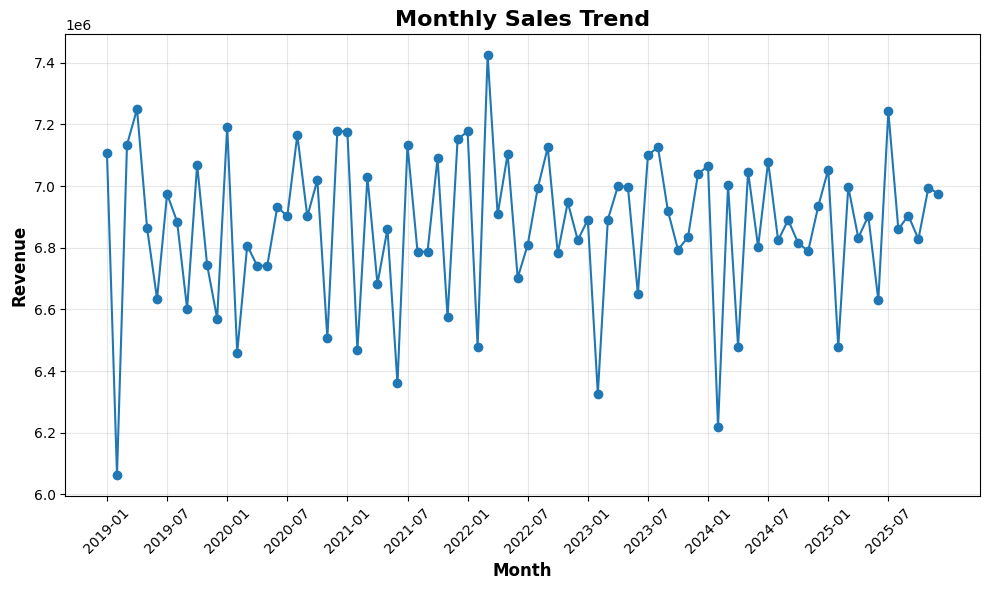

In [27]:
import matplotlib.pyplot as plt

# monthly = df.groupby('Month')['Revenue'].sum()

plt.figure(figsize=(10,6))

# Line + markers
plt.plot(monthly.index.astype(str), monthly.values, marker='o')

# Titles
plt.title("Monthly Sales Trend", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=12, fontweight='bold')
plt.ylabel("Revenue", fontsize=12, fontweight='bold')

# X-axis clean (skip some labels)
plt.xticks(ticks=range(0, len(monthly), 6), 
           labels=monthly.index.astype(str)[::6],
           rotation=45)

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# GRAPH 2 → CATEGORY-WISE REVENUE

In [28]:
# CATEGORY CLEAN
df['category'] = df['category'].str.upper().str.strip()

# Fix spelling issue
df['category'] = df['category'].replace({
    'ELETRONICS': 'ELECTRONICS'
})
# group data
category = df.groupby('category')['Revenue'].sum().sort_values(ascending=False)

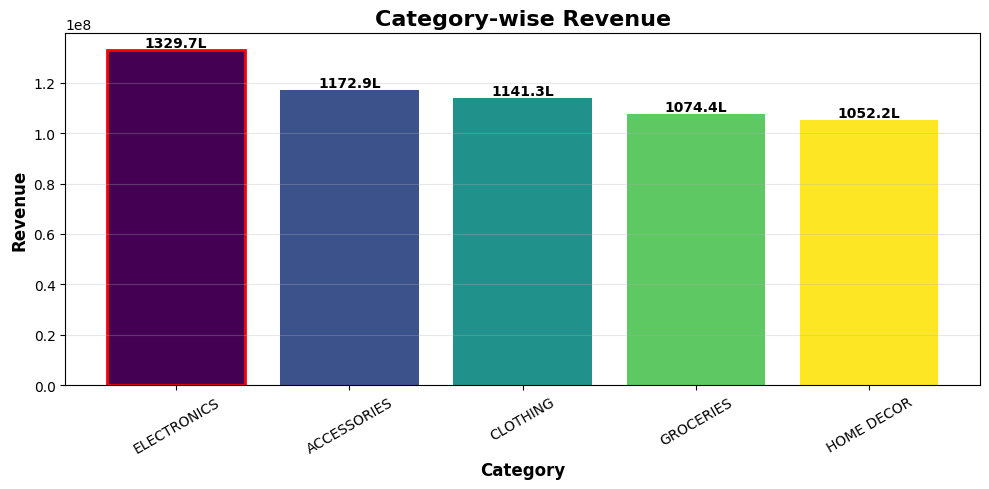

In [30]:
# GRAPH
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

# Gradient colors
colors = plt.cm.viridis(np.linspace(0,1,len(category)))

bars = plt.bar(category.index, category.values, color=colors)

# Title
plt.title("Category-wise Revenue", fontsize=16, fontweight='bold')
plt.xlabel("Category", fontsize=12, fontweight='bold')
plt.ylabel("Revenue", fontsize=12, fontweight='bold')

# Rotate labels
plt.xticks(rotation=30)

# Data labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f'{yval/100000:.1f}L',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Grid
plt.grid(axis='y', alpha=0.3)

# HIGHLIGHT TOP CATEGORY
bars[0].set_edgecolor('RED')
bars[0].set_linewidth(2)

plt.tight_layout()
plt.show()

# Graph 3 → City-wise Revenue

In [31]:
# step 1: DATA CLEAN
df['city'] = df['city'].str.upper().str.strip()

# Remove unwanted values
df = df[~df['city'].isin(['NAN', 'UNKNOWN', ''])]

# STEP 2: GROUP + TOP 5
city = df.groupby('city')['Revenue'].sum().sort_values(ascending=False).head(5)

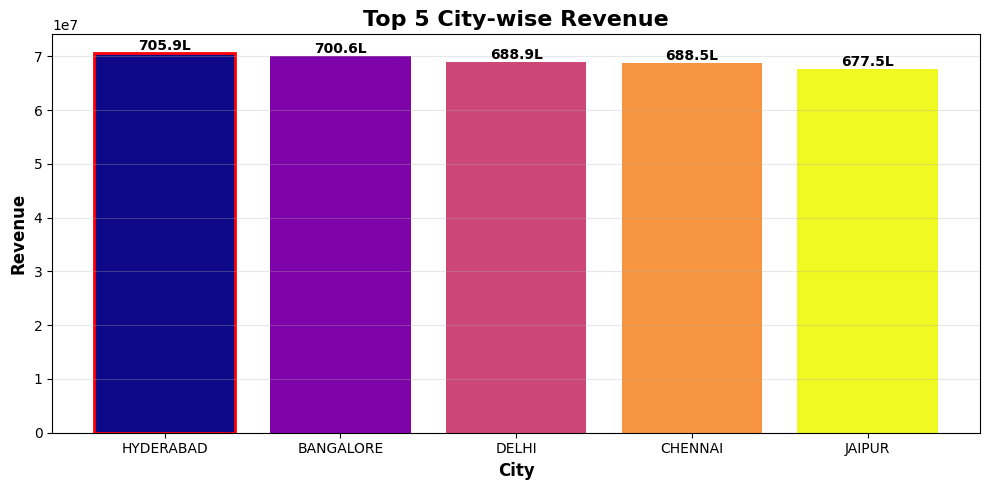

In [32]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

# Gradient colors
colors = plt.cm.plasma(np.linspace(0,1,len(city)))

bars = plt.bar(city.index, city.values, color=colors)

# Title
plt.title("Top 5 City-wise Revenue", fontsize=16, fontweight='bold')
plt.xlabel("City", fontsize=12, fontweight='bold')
plt.ylabel("Revenue", fontsize=12, fontweight='bold')

# Data labels (Lakhs)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f'{yval/100000:.1f}L',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Highlight top city
bars[0].set_edgecolor('RED')
bars[0].set_linewidth(2)

# Grid
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# GRAPH 4 → Age vs Revenue (Scatter Plot)

In [33]:
# STEP 1: DATA CLEAN
df = df[df['Revenue'] > 0]   # negative hatao

# AGGREGATE (har age ka average revenue)
age_rev = df.groupby('age')['Revenue'].mean().reset_index()

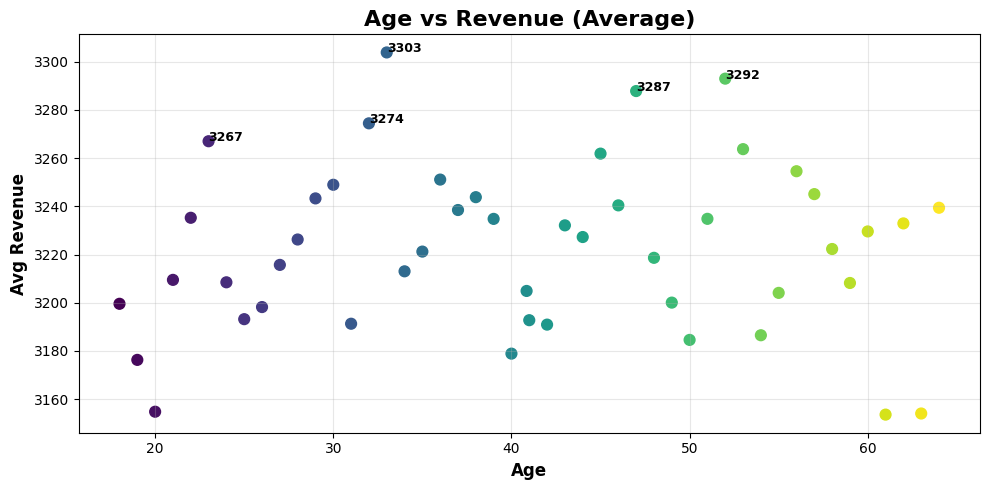

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

# Gradient colors
colors = plt.cm.viridis(np.linspace(0,1,len(age_rev)))

# Scatter
plt.scatter(age_rev['age'], age_rev['Revenue'], c=colors, s=60)

# Titles
plt.title("Age vs Revenue (Average)", fontsize=16, fontweight='bold')
plt.xlabel("Age", fontsize=12, fontweight='bold')
plt.ylabel("Avg Revenue", fontsize=12, fontweight='bold')

# Top 5 points label only (clean look)
top5 = age_rev.sort_values(by='Revenue', ascending=False).head(5)

for _, row in top5.iterrows():
    plt.text(row['age'], row['Revenue'],
             f"{int(row['Revenue'])}",
             fontsize=9, fontweight='bold')

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# GRAPH 5 → Correlation heatmap

In [35]:
# STEP 1: NUMERIC DATA SELECT
corr = df[['age', 'qty', 'price', 'Revenue', 'cost_price']].corr()
corr

,age,qty,price,Revenue,cost_price
age,1.000000,0.000892,-0.000471,0.000599,-0.001736
qty,0.000892,1.000000,0.001941,0.676442,0.002745
price,-0.000471,0.001941,1.000000,0.676052,0.908447
Revenue,0.000599,0.676442,0.676052,1.000000,0.614407
cost_price,-0.001736,0.002745,0.908447,0.614407,1.000000


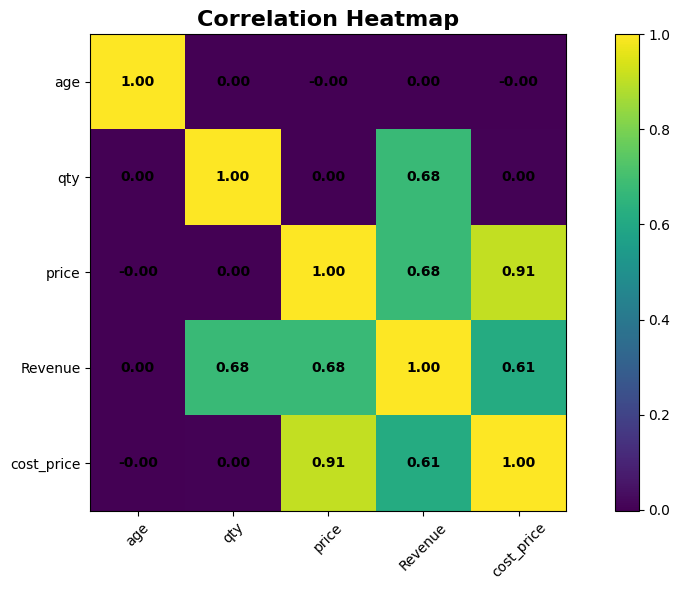

In [38]:
# STEP 2: PRO HEATMAP

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.imshow(corr)

# Axis labels
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

# Title
plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')

# Color bar
plt.colorbar()

# Values show inside
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                 ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Graph 6 → Revenue & Profit Distribution

In [39]:
# step 1 PROFIT COLUMN CREATE
df['Profit'] = df['Revenue'] - df['cost_price']
df = df[df['Profit'] > 0]   # negative hatao (clean look)

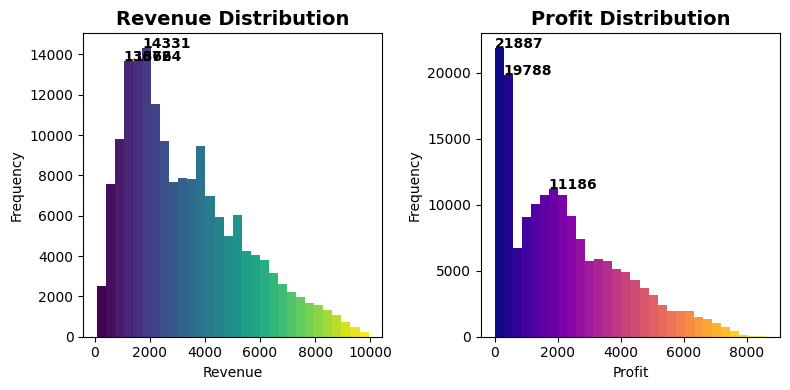

In [42]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,4))

# -------- Revenue --------
plt.subplot(1,2,1)

counts, bins, patches = plt.hist(df['Revenue'], bins=30)

# Gradient color apply
colors = plt.cm.viridis(np.linspace(0,1,len(patches)))
for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

plt.title("Revenue Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Revenue")
plt.ylabel("Frequency")

# Top 3 bars label
top_idx = np.argsort(counts)[-3:]
for i in top_idx:
    plt.text(bins[i], counts[i], int(counts[i]), fontweight='bold')


# -------- Profit --------
plt.subplot(1,2,2)

counts2, bins2, patches2 = plt.hist(df['Profit'], bins=30)

# Gradient color
colors2 = plt.cm.plasma(np.linspace(0,1,len(patches2)))
for patch, color in zip(patches2, colors2):
    patch.set_facecolor(color)

plt.title("Profit Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Profit")
plt.ylabel("Frequency")

# Top 3 bars label
top_idx2 = np.argsort(counts2)[-3:]
for i in top_idx2:
    plt.text(bins2[i], counts2[i], int(counts2[i]), fontweight='bold')

plt.tight_layout()
plt.show()

# PHASE 6 — ADVANCED ANALYSIS

In [41]:
# STEP 1 → TOP CUSTOMER ANALYSIS
top_customers = df.groupby('name')['Revenue'].sum().sort_values(ascending=False).head(5)
top_customers

name
Customer_6915    132631.602350
Customer_1246    126569.000000
Customer_4630    126373.660007
Customer_2749    126120.829413
Customer_4503    125442.056917
Name: Revenue, dtype: float64

In [42]:
# STEP 2 → BEST & WORST CATEGORY
category_perf = df.groupby('category')['Revenue'].sum().sort_values(ascending=False)

best_category = category_perf.head(1)
worst_category = category_perf.tail(1)

category_perf

category
ELECTRONICS    1.272688e+08
ACCESSORIES    1.117107e+08
CLOTHING       1.089105e+08
GROCERIES      1.022985e+08
HOME DECOR     1.004067e+08
Name: Revenue, dtype: float64

In [43]:
# STEP 3 → YEAR-OVER-YEAR (YoY) GROWTH

# STEP 3.1 → Year-wise revenue
yearly = df.groupby('Year')['Revenue'].sum()
yearly

Year
2019    7.814446e+07
2020    7.901646e+07
2021    7.820695e+07
2022    7.969021e+07
2023    7.886078e+07
2024    7.788612e+07
2025    7.879030e+07
Name: Revenue, dtype: float64

In [48]:
yoy_df = pd.DataFrame({
    'Revenue': yearly,
    'Growth %': yoy
})

yoy_df
yoy_df = yoy_df.dropna()
yoy_df

,Revenue,Growth %
Year,,
2020,7.901646e+07,1.115882
2021,7.820695e+07,-1.024480
2022,7.969021e+07,1.896576
2023,7.886078e+07,-1.040812
2024,7.788612e+07,-1.235931
2025,7.879030e+07,1.160906


In [49]:
# STEP 4 → City Profitability

# STEP 4.1 → City-wise Revenue & Profit
city_perf = df.groupby('city').agg({
    'Revenue': 'sum',
    'Profit': 'sum'
}).sort_values(by='Profit', ascending=False)

city_perf

,Revenue,Profit
city,,
HYDERABAD,7.087032e+07,4.822684e+07
BANGALORE,7.031098e+07,4.791481e+07
DELHI,6.917911e+07,4.727514e+07
CHENNAI,6.912854e+07,4.696175e+07
JAIPUR,6.798467e+07,4.644466e+07
MUMBAI,6.798649e+07,4.630110e+07
AHMEDABAD,6.784340e+07,4.608987e+07
KOLKATA,6.729177e+07,4.596100e+07


<Figure size 1200x600 with 0 Axes>

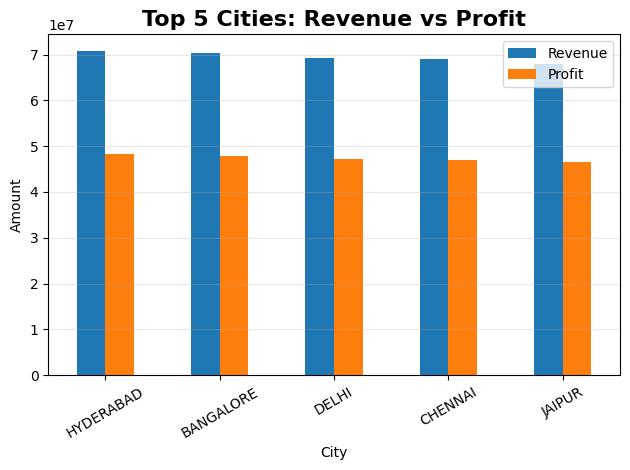

In [52]:
# STEP 4.2 → PROFESSIONAL CHART
import matplotlib.pyplot as plt

city_perf_top = city_perf.head(5)

plt.figure(figsize=(12,6))

city_perf_top[['Revenue','Profit']].plot(kind='bar')

plt.title("Top 5 Cities: Revenue vs Profit", fontsize=16, fontweight='bold')
plt.xlabel("City")
plt.ylabel("Amount")

plt.xticks(rotation=30)

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# Profit margin
city_perf['Profit Margin %'] = (city_perf['Profit'] / city_perf['Revenue']) * 100
city_perf

,Revenue,Profit,Profit Margin %
city,,,
HYDERABAD,7.087032e+07,4.822684e+07,68.049411
BANGALORE,7.031098e+07,4.791481e+07,68.146985
DELHI,6.917911e+07,4.727514e+07,68.337304
CHENNAI,6.912854e+07,4.696175e+07,67.933956
JAIPUR,6.798467e+07,4.644466e+07,68.316366
MUMBAI,6.798649e+07,4.630110e+07,68.103379
AHMEDABAD,6.784340e+07,4.608987e+07,67.935678
KOLKATA,6.729177e+07,4.596100e+07,68.301073


In [55]:
# STEP 5 → Customer Lifetime Value (CLV)
clv = df.groupby('name').agg({
    'Revenue': 'sum',
    'order_id': 'count'
}).rename(columns={'order_id': 'Total Orders'})

clv

,Revenue,Total Orders
name,,
Customer_1,69824.000000,21
Customer_10,62897.337146,16
Customer_100,66638.887126,20
Customer_1000,38414.000000,12
Customer_10000,53250.776774,22
...,...,...
Customer_9994,51811.828807,17
Customer_9996,69833.083247,21
Customer_9997,64146.752357,16


In [56]:
# STEP 5.2 → AVERAGE VALUE
clv['Avg Order Value'] = clv['Revenue'] / clv['Total Orders']
clv

,Revenue,Total Orders,Avg Order Value
name,,,
Customer_1,69824.000000,21,3324.952381
Customer_10,62897.337146,16,3931.083572
Customer_100,66638.887126,20,3331.944356
Customer_1000,38414.000000,12,3201.166667
Customer_10000,53250.776774,22,2420.489853
...,...,...,...
Customer_9994,51811.828807,17,3047.754636
Customer_9996,69833.083247,21,3325.384917
Customer_9997,64146.752357,16,4009.172022


In [57]:
# STEP 5.3 → TOP CUSTOMERS
top_clv = clv.sort_values(by='Revenue', ascending=False).head(10)
top_clv

,Revenue,Total Orders,Avg Order Value
name,,,
Customer_6915,132631.602350,29,4573.503529
Customer_1246,126569.000000,33,3835.424242
Customer_4630,126373.660007,30,4212.455334
Customer_2749,126120.829413,30,4204.027647
Customer_4503,125442.056917,32,3920.064279
Customer_4553,124039.000000,27,4594.037037
Customer_8096,122894.218972,38,3234.058394
Customer_9610,121206.828807,29,4179.545821
Customer_9616,120839.914404,29,4166.893600


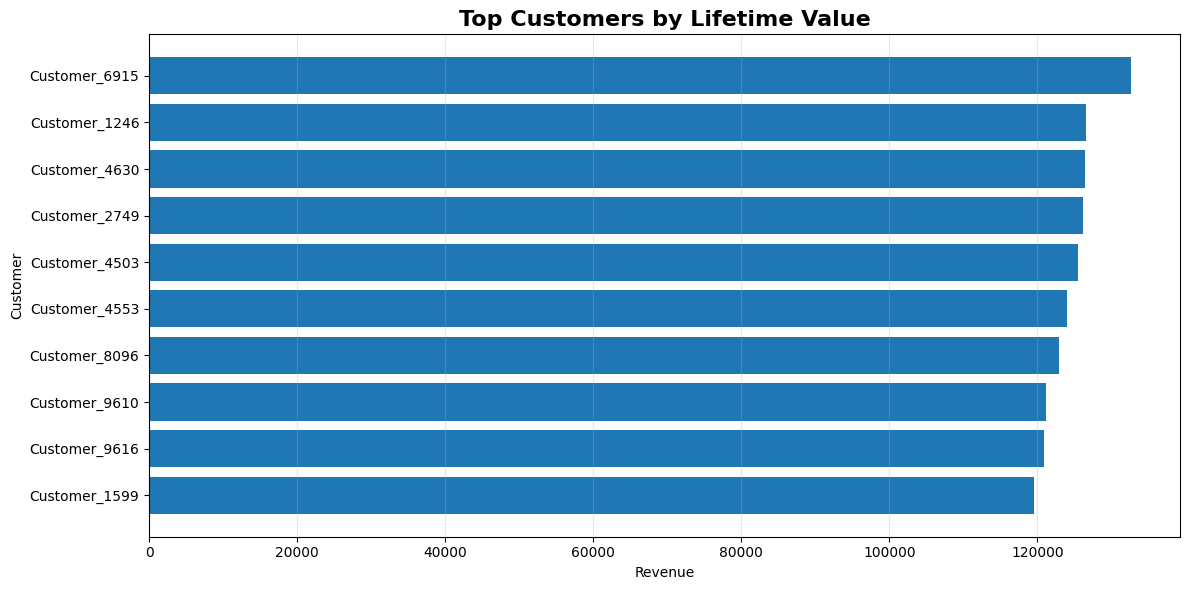

In [58]:
# STEP 5.4 → PROFESSIONAL CHART

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(top_clv.index, top_clv['Revenue'])

plt.title("Top Customers by Lifetime Value", fontsize=16, fontweight='bold')
plt.xlabel("Revenue")
plt.ylabel("Customer")

plt.gca().invert_yaxis()

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()